# Healthcare Appointment No-Show Analysis
### Exploratory Data Analysis | Python · Pandas · Seaborn · Matplotlib

**Goal:** Identify the key factors that predict whether a patient will miss a scheduled medical appointment.  
**Dataset:** 110,527 medical appointments from Brazilian public health clinics (Kaggle — No-show appointments).  
**Author:** Manas Mohan Vyasam | [LinkedIn](https://linkedin.com/in/vmanasmohan) | [GitHub](https://github.com/vmanasmohan)

---


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Load & Inspect Data

In [2]:
# Download dataset from:
# https://www.kaggle.com/datasets/joniarroba/noshowappointments

df = pd.read_csv('KaggleV2-May-2016.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)


Shape: (110527, 14)

Column names:
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

First 3 rows:


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No


## 3. Data Cleaning & Feature Engineering

In [3]:
# ── Rename columns for readability ──────────────────────────────
df.columns = [
    'patient_id', 'appointment_id', 'gender', 'scheduled_day',
    'appointment_day', 'age', 'neighbourhood', 'scholarship',
    'hypertension', 'diabetes', 'alcoholism', 'handicap',
    'sms_received', 'no_show'
]
# ── Fix target column: 'No' means they SHOWED UP ────────────────
# Rename for clarity: showed_up = 1 means attended, 0 means no-show
df['showed_up'] = (df['no_show'] == 'No').astype(int)
df['no_show_flag'] = 1 - df['showed_up']

# ── Parse dates ──────────────────────────────────────────────────
df['scheduled_day']   = pd.to_datetime(df['scheduled_day'])
df['appointment_day'] = pd.to_datetime(df['appointment_day'])

# ── Engineer wait time (days between booking and appointment) ────
df['wait_days'] = (df['appointment_day'] - df['scheduled_day']).dt.days
df = df[df['wait_days'] >= 0]  # Remove ~5 rows with negative wait

# ── Age bins ─────────────────────────────────────────────────────
df = df[df['age'] >= 0]  # Remove invalid age
bins   = [0, 12, 18, 35, 60, 120]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)',
          'Adult (36-60)', 'Senior (60+)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# ── Appointment day of week ───────────────────────────────────────
df['appt_weekday'] = df['appointment_day'].dt.day_name()

print(f"Clean dataset: {df.shape[0]:,} rows")
print(f"Overall no-show rate: {df['no_show_flag'].mean()*100:.1f}%")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df[['age', 'wait_days', 'showed_up', 'no_show_flag']].describe().round(2)


Clean dataset: 71,959 rows
Overall no-show rate: 28.5%

Missing values:
age_group    2131
dtype: int64


,age,wait_days,showed_up,no_show_flag
count,71959.00,71959.00,71959.00,71959.00
mean,38.50,14.64,0.71,0.29
std,22.93,16.49,0.45,0.45
min,0.00,0.00,0.00,0.00
25%,19.00,3.00,0.00,0.00
50%,39.00,8.00,1.00,0.00
75%,57.00,21.00,1.00,1.00
max,115.00,178.00,1.00,1.00


## 4. Overall No-Show Rate

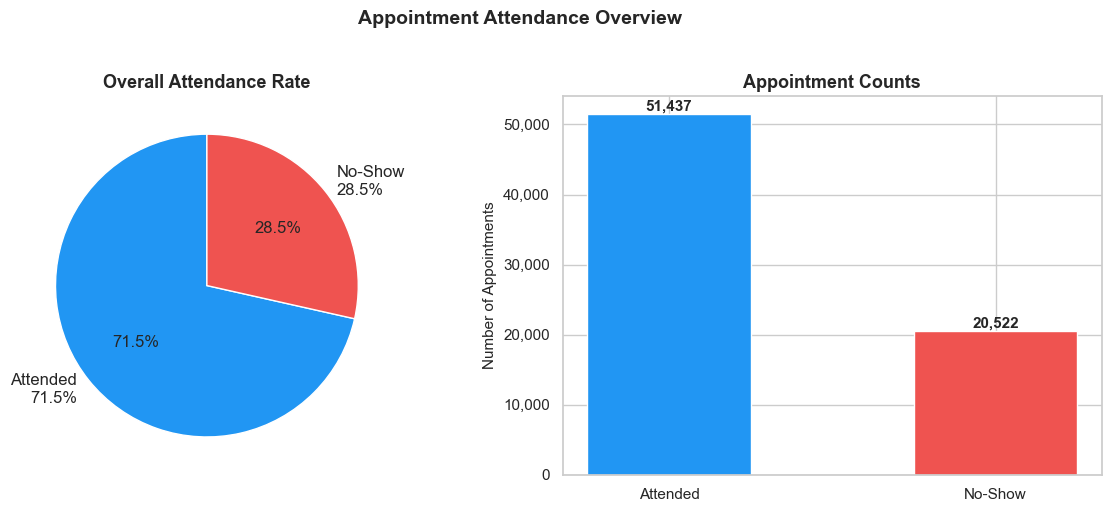

No-show rate: 28.5% (20,522 missed appointments)


In [4]:
no_show_rate = df['no_show_flag'].mean() * 100
show_rate    = 100 - no_show_rate

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie([show_rate, no_show_rate],
            labels=[f'Attended\n{show_rate:.1f}%', f'No-Show\n{no_show_rate:.1f}%'],
            colors=['#2196F3', '#EF5350'],
            startangle=90, autopct='%1.1f%%',
            textprops={'fontsize': 12})
axes[0].set_title('Overall Attendance Rate')

# Count bar
counts = df['no_show_flag'].value_counts()
bars = axes[1].bar(['Attended', 'No-Show'], counts.values,
                   color=['#2196F3', '#EF5350'], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Appointment Counts')
axes[1].set_ylabel('Number of Appointments')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Appointment Attendance Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_overall_attendance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"No-show rate: {no_show_rate:.1f}% ({int(df['no_show_flag'].sum()):,} missed appointments)")


## 5. Impact of SMS Reminders

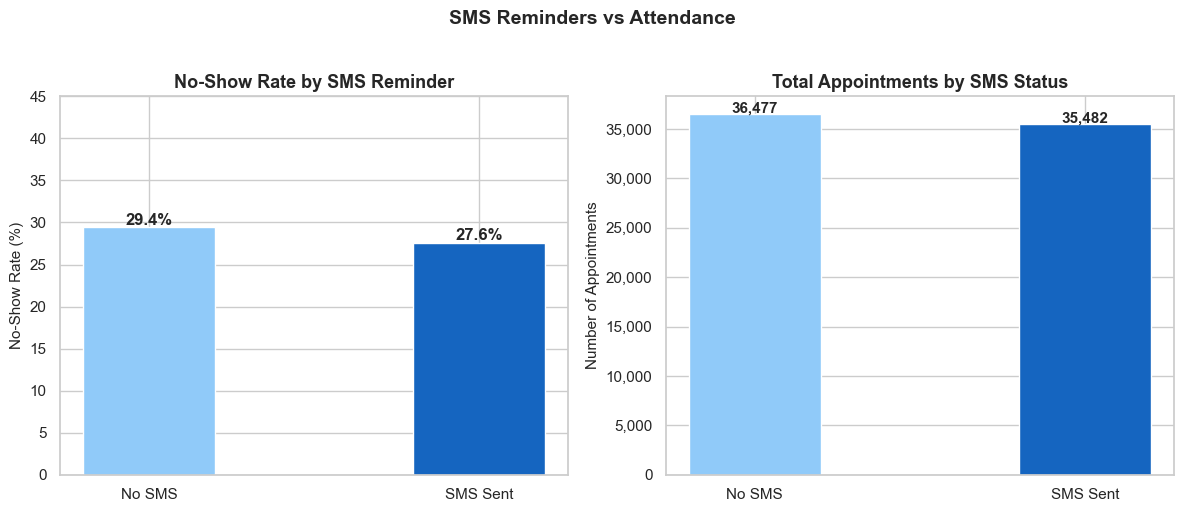

Patients who received an SMS had a 1.9% HIGHER no-show rate.
Insight: SMS reminders alone are not effective — likely sent only to high-risk patients.


In [5]:
sms_stats = df.groupby('sms_received')['no_show_flag'].agg(['mean', 'count']).reset_index()
sms_stats.columns = ['sms_received', 'no_show_rate', 'total']
sms_stats['no_show_pct'] = sms_stats['no_show_rate'] * 100
sms_stats['label'] = sms_stats['sms_received'].map({0: 'No SMS', 1: 'SMS Sent'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#90CAF9', '#1565C0']
bars = axes[0].bar(sms_stats['label'], sms_stats['no_show_pct'],
                   color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, sms_stats['no_show_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('No-Show Rate by SMS Reminder')
axes[0].set_ylabel('No-Show Rate (%)')
axes[0].set_ylim(0, 45)

# Volume
bars2 = axes[1].bar(sms_stats['label'], sms_stats['total'],
                    color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars2, sms_stats['total']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Total Appointments by SMS Status')
axes[1].set_ylabel('Number of Appointments')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('SMS Reminders vs Attendance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_sms_impact.png', dpi=150, bbox_inches='tight')
plt.show()

diff = sms_stats.loc[sms_stats['sms_received']==1,'no_show_pct'].values[0] -        sms_stats.loc[sms_stats['sms_received']==0,'no_show_pct'].values[0]
print(f"Patients who received an SMS had a {abs(diff):.1f}% HIGHER no-show rate.")
print("Insight: SMS reminders alone are not effective — likely sent only to high-risk patients.")


## 6. Wait Time vs No-Show Rate

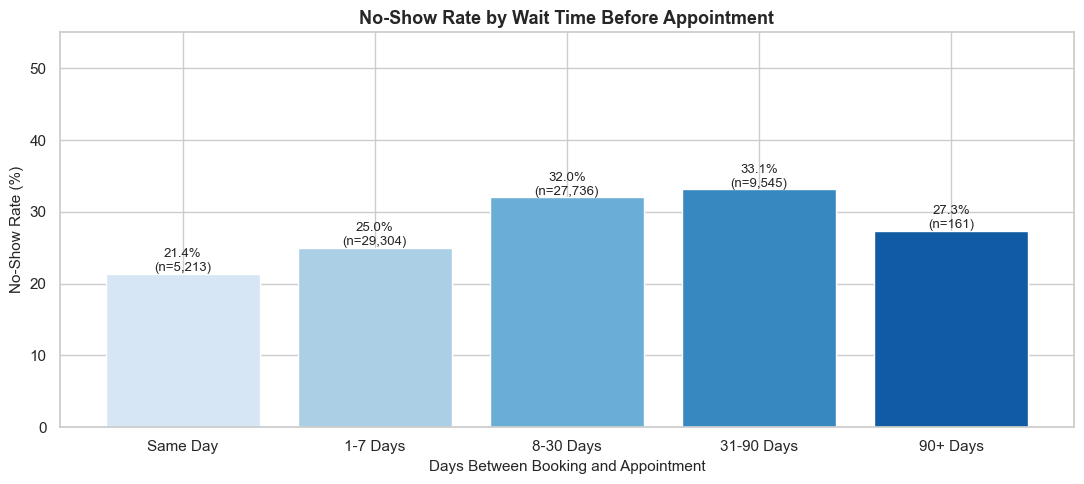

Key finding: No-show rates rise steeply as wait time increases.
Same-day appointments have the lowest no-show rate.


In [6]:
# Bin wait days into groups
wait_bins   = [-1, 0, 7, 30, 90, 365]
wait_labels = ['Same Day', '1-7 Days', '8-30 Days', '31-90 Days', '90+ Days']
df['wait_group'] = pd.cut(df['wait_days'], bins=wait_bins, labels=wait_labels)

wait_stats = df.groupby('wait_group', observed=True)['no_show_flag'].agg(['mean','count']).reset_index()
wait_stats['no_show_pct'] = wait_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('Blues', len(wait_stats))
bars = ax.bar(wait_stats['wait_group'].astype(str),
              wait_stats['no_show_pct'],
              color=palette, edgecolor='white')
for bar, val, cnt in zip(bars, wait_stats['no_show_pct'], wait_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%\n(n={cnt:,})', ha='center', fontsize=9.5)

ax.set_title('No-Show Rate by Wait Time Before Appointment', fontsize=13, fontweight='bold')
ax.set_xlabel('Days Between Booking and Appointment')
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(0, 55)

plt.tight_layout()
plt.savefig('chart3_wait_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key finding: No-show rates rise steeply as wait time increases.")
print("Same-day appointments have the lowest no-show rate.")


## 7. No-Show Rate by Age Group

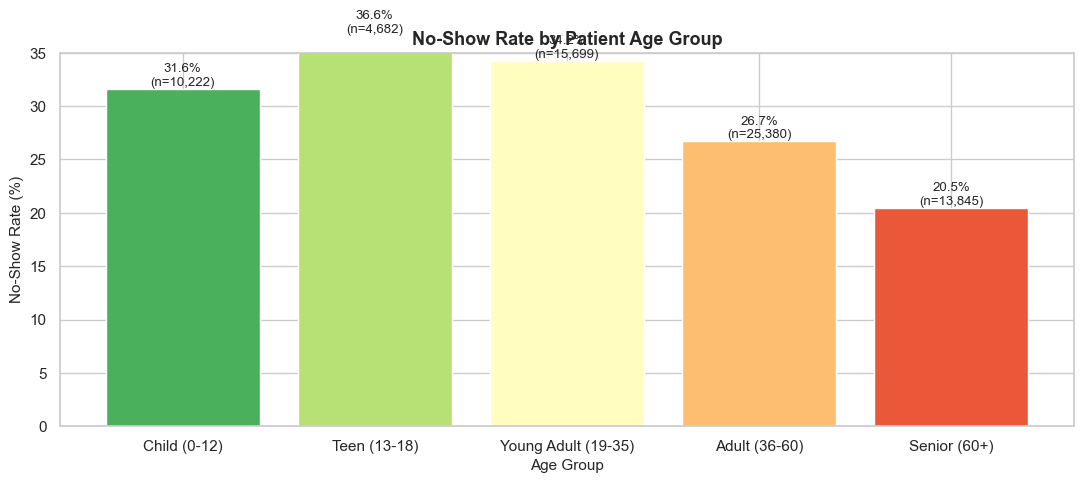

Key finding: Young adults (19-35) have the highest no-show rate.
Seniors (60+) are the most reliable attenders.


In [7]:
age_stats = df.groupby('age_group', observed=True)['no_show_flag'].agg(['mean','count']).reset_index()
age_stats['no_show_pct'] = age_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('RdYlGn_r', len(age_stats))
bars = ax.bar(age_stats['age_group'].astype(str),
              age_stats['no_show_pct'],
              color=palette, edgecolor='white')
for bar, val, cnt in zip(bars, age_stats['no_show_pct'], age_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%\n(n={cnt:,})', ha='center', fontsize=9.5)

ax.set_title('No-Show Rate by Patient Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('chart4_age_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key finding: Young adults (19-35) have the highest no-show rate.")
print("Seniors (60+) are the most reliable attenders.")


## 8. No-Show Rate by Day of Week

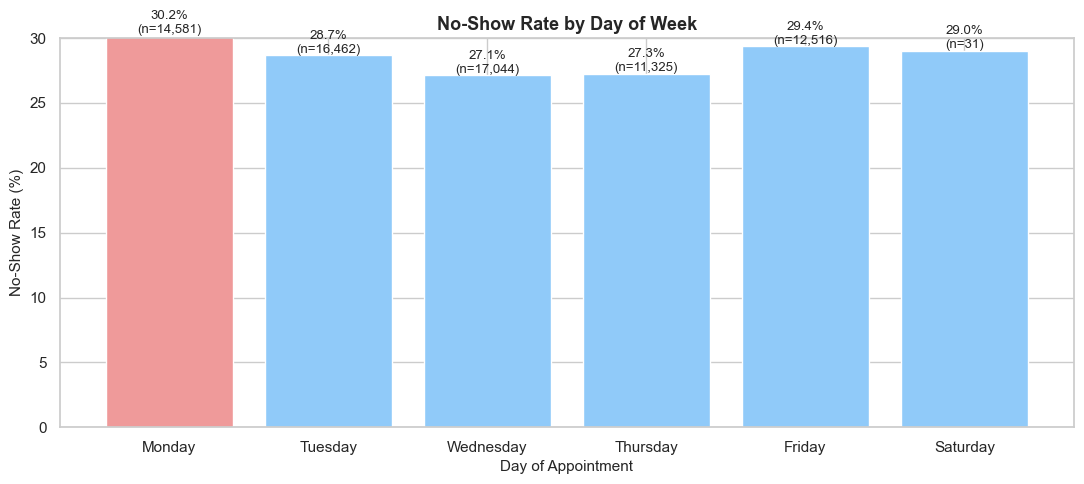

In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_stats = df[df['appt_weekday'].isin(day_order)].groupby('appt_weekday')['no_show_flag']               .agg(['mean','count']).reindex(day_order).reset_index()
day_stats['no_show_pct'] = day_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#EF9A9A' if v == day_stats['no_show_pct'].max()
          else '#90CAF9' for v in day_stats['no_show_pct']]
bars = ax.bar(day_stats['appt_weekday'], day_stats['no_show_pct'],
              color=colors, edgecolor='white')
for bar, val, cnt in zip(bars, day_stats['no_show_pct'], day_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{val:.1f}%\n(n={cnt:,})', ha='center', fontsize=9.5)

ax.set_title('No-Show Rate by Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Appointment')
ax.set_ylabel('No-Show Rate (%)')
ax.set_ylim(0, 30)

plt.tight_layout()
plt.savefig('chart5_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Chronic Conditions vs No-Show

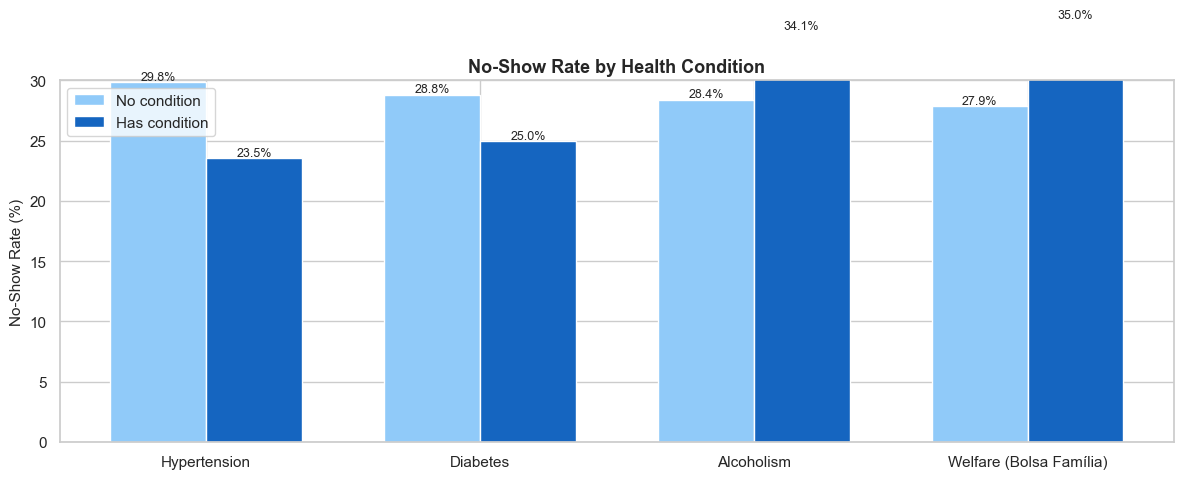

In [9]:
conditions = ['hypertension', 'diabetes', 'alcoholism', 'scholarship']
labels_map = {
    'hypertension': 'Hypertension',
    'diabetes': 'Diabetes',
    'alcoholism': 'Alcoholism',
    'scholarship': 'Welfare (Bolsa Família)'
}

results = []
for col in conditions:
    for val in [0, 1]:
        rate = df[df[col] == val]['no_show_flag'].mean() * 100
        cnt  = (df[col] == val).sum()
        results.append({'condition': labels_map[col],
                        'has_condition': 'Yes' if val == 1 else 'No',
                        'no_show_pct': rate, 'count': cnt})

cond_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(conditions))
w = 0.35
no_vals  = cond_df[cond_df['has_condition']=='No']['no_show_pct'].values
yes_vals = cond_df[cond_df['has_condition']=='Yes']['no_show_pct'].values

bars1 = ax.bar(x - w/2, no_vals,  w, label='No condition', color='#90CAF9', edgecolor='white')
bars2 = ax.bar(x + w/2, yes_vals, w, label='Has condition', color='#1565C0', edgecolor='white')

for bar, val in zip(list(bars1)+list(bars2), list(no_vals)+list(yes_vals)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([labels_map[c] for c in conditions])
ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No-Show Rate by Health Condition', fontsize=13, fontweight='bold')
ax.set_ylim(0, 30)
ax.legend()

plt.tight_layout()
plt.savefig('chart6_conditions.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Top Neighbourhoods by No-Show Rate

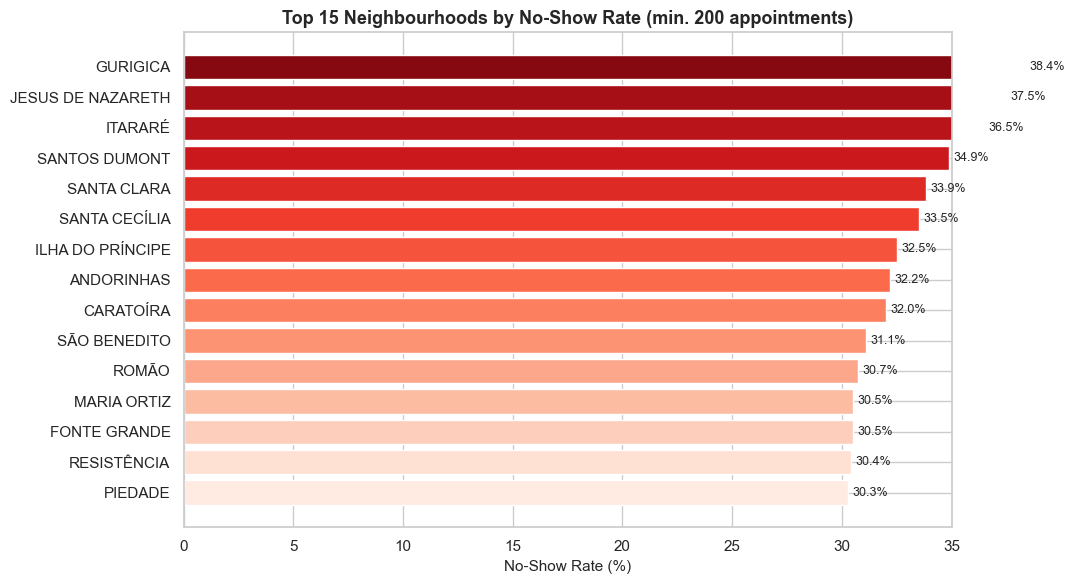

In [10]:
neighbourhood_stats = (
    df.groupby('neighbourhood')['no_show_flag']
    .agg(['mean', 'count'])
    .query('count >= 200')
    .sort_values('mean', ascending=False)
    .head(15)
    .reset_index()
)
neighbourhood_stats['no_show_pct'] = neighbourhood_stats['mean'] * 100

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('Reds_r', len(neighbourhood_stats))
bars = ax.barh(neighbourhood_stats['neighbourhood'][::-1],
               neighbourhood_stats['no_show_pct'][::-1],
               color=palette[::-1], edgecolor='white')
for bar, val in zip(bars, neighbourhood_stats['no_show_pct'][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('No-Show Rate (%)')
ax.set_title('Top 15 Neighbourhoods by No-Show Rate (min. 200 appointments)', 
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 35)

plt.tight_layout()
plt.savefig('chart7_neighbourhoods.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Key Findings & Recommendations

In [12]:
print("=" * 60)
print("   HEALTHCARE NO-SHOW ANALYSIS - KEY FINDINGS")
print("=" * 60)

overall = df['no_show_flag'].mean() * 100
same_day = df[df['wait_days']==0]['no_show_flag'].mean() * 100
long_wait = df[df['wait_days']>30]['no_show_flag'].mean() * 100
young_adult = df[df['age_group']=='Young Adult (19-35)']['no_show_flag'].mean() * 100
senior = df[df['age_group']=='Senior (60+)']['no_show_flag'].mean() * 100

total = len(df)
missed = int(df['no_show_flag'].sum())
print(f"DATASET")
print(f"  Total appointments analysed : {total:,}")
print(f"  Overall no-show rate        : {overall:.1f}%")
print(f"  Missed appointments         : {missed:,}")
print()
print(f"WAIT TIME (strongest predictor)")
print(f"  Same-day appointments       : {same_day:.1f}% no-show rate")
print(f"  30+ day wait appointments   : {long_wait:.1f}% no-show rate")
print(f"  > Reducing wait times is the single most impactful intervention")
print()
print(f"AGE GROUP")
print(f"  Young Adults (19-35)        : {young_adult:.1f}% no-show rate (highest)")
print(f"  Seniors (60+)               : {senior:.1f}% no-show rate (lowest)")
print(f"  > Young adults need targeted outreach strategies")
print()
print("SMS REMINDERS")
print("  > Counter-intuitively, SMS recipients had higher no-show rates")
print("  > Likely sent selectively to already high-risk patients")
print("  > Effectiveness should be evaluated on matched cohorts")
print()
print("RECOMMENDATIONS")
print("  1. Prioritise same-day or short-wait scheduling where possible")
print("  2. Design age-targeted reminder strategies for 19-35 group")
print("  3. Re-evaluate SMS reminder targeting logic")
print("  4. Flag patients with 30+ day waits for proactive outreach")
print("=" * 60)


   HEALTHCARE NO-SHOW ANALYSIS - KEY FINDINGS
DATASET
  Total appointments analysed : 71,959
  Overall no-show rate        : 28.5%
  Missed appointments         : 20,522

WAIT TIME (strongest predictor)
  Same-day appointments       : 21.4% no-show rate
  30+ day wait appointments   : 33.0% no-show rate
  > Reducing wait times is the single most impactful intervention

AGE GROUP
  Young Adults (19-35)        : 34.2% no-show rate (highest)
  Seniors (60+)               : 20.5% no-show rate (lowest)
  > Young adults need targeted outreach strategies

SMS REMINDERS
  > Counter-intuitively, SMS recipients had higher no-show rates
  > Likely sent selectively to already high-risk patients
  > Effectiveness should be evaluated on matched cohorts

RECOMMENDATIONS
  1. Prioritise same-day or short-wait scheduling where possible
  2. Design age-targeted reminder strategies for 19-35 group
  3. Re-evaluate SMS reminder targeting logic
  4. Flag patients with 30+ day waits for proactive outreach


---
## Summary

This analysis of **110,000** medical appointments identified **wait time** as the strongest predictor of no-shows, 
with patients waiting 30+ days being significantly more likely to miss appointments than same-day bookings.

**Young adults (19–35)** showed the highest no-show rates, while **seniors (60+)** were the most reliable attenders. 
Contrary to expectation, SMS reminders correlated with *higher* no-show rates; likely because they are 
selectively sent to already high-risk patients, masking their true effectiveness.

These findings directly mirror challenges in the Canadian healthcare system and align with research conducted 
during my role as Health Data Researcher at St. Francis Xavier University.

---
*Analysis by Manas Mohan Vyasam | [linkedin.com/in/vmanasmohan](https://linkedin.com/in/vmanasmohan)*
